In [1]:
import torch
from ase.io import read
from mattersim.forcefield import MatterSimCalculator
from sklearn.metrics import mean_absolute_error
import wandb
import matplotlib.pyplot as plt
import numpy as np

2025-12-11 08:37:10.712 | INFO     | mattersim.forcefield.potential:from_checkpoint:893 - Loading the model from /Users/bug9g/Datasets_and_Weights/Trained_MS/best_model.pth


In [ ]:
#Using Mattersim to Predict Energies
atoms_list = read("/Users/bug9g/Datasets and Weights/val.xyz", index=":")

best_model = "/Users/bug9g/Datasets and Weights/best_model_CH.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"
calc = MatterSimCalculator(load_path=best_model, device=device)
energies = []
for i, atoms in enumerate(atoms_list):
    atoms.calc = calc
    E = atoms.get_potential_energy() / len(atoms)
    energies.append(E)

/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 34.3762x34.3762x34.3762 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 29.441899999999997x29.441899999999997x29.441899999999997 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 29.519599999999997x29.519599999999997x29.519599999999997 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 31.623800000000003x31.6

In [2]:
#Validation 
atoms_list = read("/Users/bug9g/Datasets_and_Weights/test.xyz", index=":")

best_model = "/Users/bug9g/Datasets_and_Weights/Trained_MS/best_model.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"
calc = MatterSimCalculator(load_path=best_model, device=device)
energies = []
for i, atoms in enumerate(atoms_list):
    atoms.calc = calc
    E = atoms.get_potential_energy() / len(atoms)
    energies.append(E)
y_true = []
with open("/Users/bug9g/Datasets_and_Weights/test.xyz") as f:
    while True:
        line = f.readline()
        if not line:
            break
        n_atoms = int(line)
        comment = f.readline().strip()
        y_true.append(float(comment.split("=")[1]) / n_atoms)
        for _ in range(n_atoms):
            f.readline()
mae_best = mean_absolute_error(y_true, energies)
print(f'MAE train model:{mae_best}')

/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 34.3762x34.3762x34.3762 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 29.441899999999997x29.441899999999997x29.441899999999997 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 29.519599999999997x29.519599999999997x29.519599999999997 Angstrom**3
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/mattersim/lib/python3.9/site-packages/mattersim/datasets/utils/convertor.py:210: UserWarning: No PBC detected, using a large supercell with size 31.623800000000003x31.6

MAE train model:0.0008749549690143905


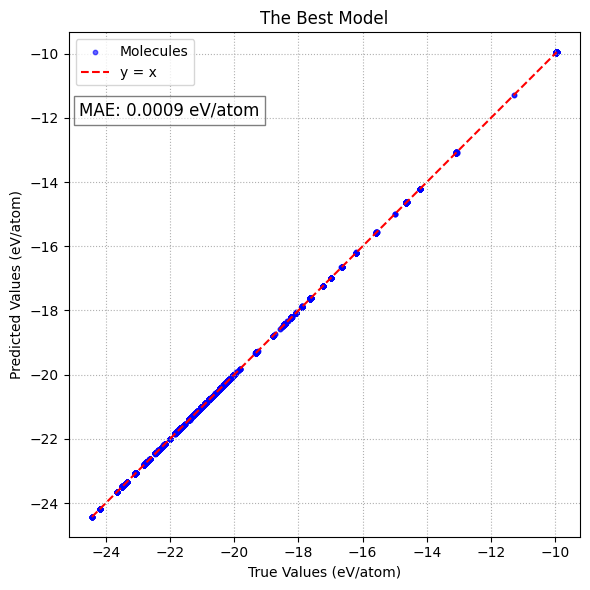

In [12]:
#Parity Plot
min_val = min(min(y_true), min(energies))
max_val = max(max(y_true), max(energies))

plt.figure(figsize=(6,6))
plt.scatter(y_true, energies, s=10, alpha=0.6, color='blue', label='Molecules')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='y = x')
plt.figtext(0.14, 0.8, f'MAE: {mae_best:.4f} eV/atom', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Values (eV/atom)')
plt.ylabel('Predicted Values (eV/atom)')
plt.title('The Best Model')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.axis('equal')
plt.tight_layout()
plt.show()